# Laboratorio 1 — Series de Tiempo
### Data Science | Universidad del Valle de Guatemala 

**Integrantes:** Adrián González, José Ordoñez, Alejandro Anton

Dataset: ingreso mensual de viajeros internacionales a Guatemala (2009-2026).

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
FIGS = "figs"
os.makedirs(FIGS, exist_ok=True)

## Carga de datos

In [3]:
df = pd.read_excel("Base_Migracion_2009-2026jun.xlsx")
print("Dimensiones:", df.shape)
df.dtypes

Dimensiones: (161036, 13)


Año                        int64
Mes cod                    int64
Mes                          str
Vía                          str
Frontera                     str
País                         str
Región                       str
Región dos                   str
Regiones OMT                 str
MCEO                         str
Agrupación Residencia        str
Tipo de Viajero              str
Viajero                  float64
dtype: object

## Limpieza y calidad de datos

Revisamos nulos, duplicados, valores atípicos y consistencia de categorías.

In [4]:
print("--- Nulos por columna ---")
print(df.isna().sum())
print("\n--- Duplicados exactos ---", df.duplicated().sum())

# Fecha de referencia (dia 1 de cada mes)
df["Fecha"] = pd.to_datetime(dict(year=df["Año"], month=df["Mes cod"], day=1))

# Región dos: hay valores '0' y separacion redundante
print("\n--- Valores unicos de 'Región dos' ---")
print(df["Región dos"].value_counts())

--- Nulos por columna ---
Año                      0
Mes cod                  0
Mes                      0
Vía                      0
Frontera                 0
País                     0
Región                   0
Región dos               0
Regiones OMT             0
MCEO                     0
Agrupación Residencia    0
Tipo de Viajero          0
Viajero                  0
dtype: int64

--- Duplicados exactos --- 0

--- Valores unicos de 'Región dos' ---
Región dos
Europa                         54640
América Del Centro             31362
América Del Sur y el Caribe    24734
América Del Norte              17306
Asia                           13247
Otros Paises Del Mundo          8979
Oceanía                         5746
Oriente Medio                   4805
Cruceristas                      196
0                                 13
Cruceros                           8
Name: count, dtype: int64


In [5]:
# Unificamos categorias de cruceros dentro de Región dos
df["Región dos"] = df["Región dos"].replace({"Cruceros": "Cruceristas", "0": "Sin Clasificar"})

# Viajero: cantidad de viajeros, se esperan enteros pero hay decimales -> posible
# resultado de agregaciones/estimaciones oficiales. Revisamos negativos y ceros.
print("Registros con Viajero < 0:", (df["Viajero"] < 0).sum())
print("Registros con Viajero == 0:", (df["Viajero"] == 0).sum())
print("Registros con parte decimal no entera:", (df["Viajero"] % 1 != 0).sum())

Registros con Viajero < 0: 0
Registros con Viajero == 0: 54
Registros con parte decimal no entera: 51272


In [6]:
# Outliers univariados (a nivel de registro) via IQR
q1, q3 = df["Viajero"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_sup = q3 + 3 * iqr
outliers = df[df["Viajero"] > lim_sup]
print(f"Registros por encima de Q3+3*IQR ({lim_sup:.1f}): {len(outliers)} de {len(df)}")
outliers.groupby("Tipo de Viajero")["Viajero"].agg(["count", "mean", "max"])

Registros por encima de Q3+3*IQR (149.6): 21104 de 161036


,count,mean,max
Tipo de Viajero,,,
Cruceristas,203,5439.985222,21680.933573
Excursionista,3991,2201.153453,38463.026064
Turista,13915,2582.886672,83511.000000
Viajero,2995,1366.694064,92336.035067


## Estadísticas descriptivas

In [7]:
print("--- Estadísticas descriptivas de Viajero (nivel registro) ---")
print(df["Viajero"].describe())
print("\n--- Total de viajeros por Tipo de Viajero ---")
df.groupby("Tipo de Viajero")["Viajero"].sum().sort_values(ascending=False)

--- Estadísticas descriptivas de Viajero (nivel registro) ---
count    161036.000000
mean        324.697193
std        2387.745140
min           0.000000
25%           2.000000
50%           7.000000
75%          38.891667
max       92336.035067
Name: Viajero, dtype: float64

--- Total de viajeros por Tipo de Viajero ---


Tipo de Viajero
Turista          3.764273e+07
Excursionista    9.069184e+06
Viajero          4.471622e+06
Cruceristas      1.104402e+06
Name: Viajero, dtype: float64

## Análisis Preliminar de la Serie: Total Mensual de Viajeros Internacionales

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
# Agregación mensual del total de viajeros internacionales
mensual = (df.groupby(["Año", "Mes cod"])["Viajero"]
             .sum()
             .reset_index())

fechas = pd.to_datetime(dict(year=mensual["Año"], month=mensual["Mes cod"], day=1))
ts = pd.Series(mensual["Viajero"].values, index=pd.DatetimeIndex(fechas, freq="MS"), name="total_viajeros")

print(f"Observaciones: {len(ts)}")
ts.head(10)

Observaciones: 210


2009-01-01    183505.590535
2009-02-01    149426.253908
2009-03-01    174237.227095
2009-04-01    182842.489917
2009-05-01    133194.667651
2009-06-01    156292.128571
2009-07-01    140089.275692
2009-08-01    189382.188376
2009-09-01    135790.188456
2009-10-01    156825.966667
Freq: MS, Name: total_viajeros, dtype: float64

### a. Inicio, fin y frecuencia de la serie

In [10]:
print(f"Inicio:  {ts.index[0]:%B %Y}")
print(f"Fin:     {ts.index[-1]:%B %Y}")
print(f"Frecuencia: {ts.index.freqstr}")
print(f"Total de observaciones: {len(ts)}")

Inicio:  January 2009
Fin:     June 2026
Frecuencia: MS
Total de observaciones: 210


### b. Gráfico de la serie

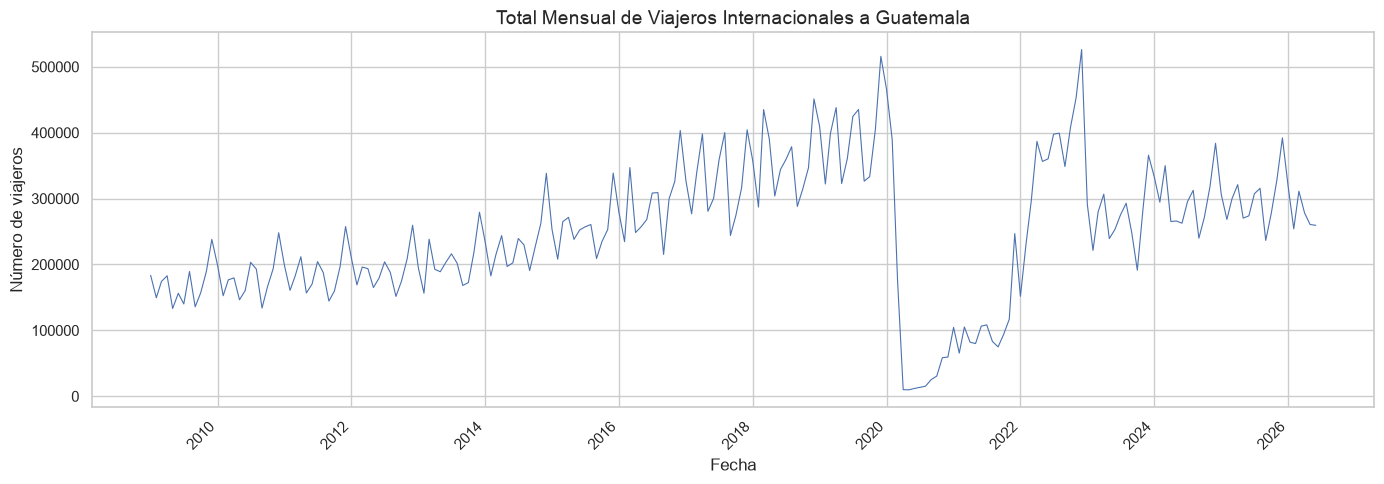

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ts.index, ts.values, linewidth=0.8)
ax.set_title("Total Mensual de Viajeros Internacionales a Guatemala", fontsize=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Número de viajeros")
fig.autofmt_xdate(rotation=45)
plt.tight_layout()
plt.savefig(f"{FIGS}/serie_mensual.png", dpi=150, bbox_inches="tight")
plt.show()

Al graficar la serie se observa una tendencia creciente a lo largo de los años, un patrón estacional claro con picos y valles repetitivos cada año, y una caída drástica alrededor de 2020 debido a la pandemia de COVID-19, la cual fue seguida de una recuperación que incluso superó los niveles pre-pandemia. También se nota que la amplitud de las oscilaciones aumenta con el tiempo, lo que sugiere que la varianza no es constante.

### c. Descomposición de la serie

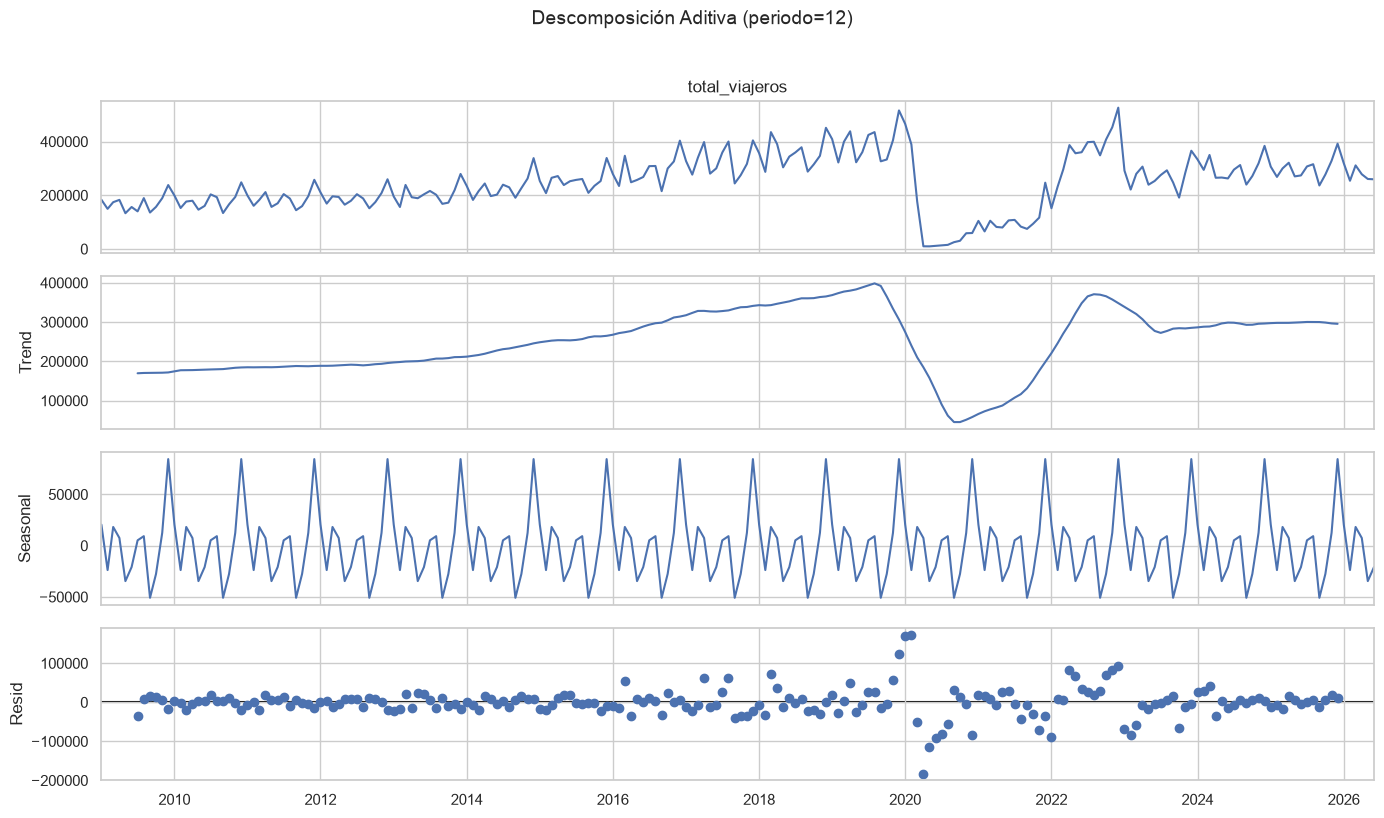

In [12]:
decomp_add = seasonal_decompose(ts, model="additive", period=12)

fig = decomp_add.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Descomposición Aditiva (periodo=12)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGS}/descomposicion_aditiva.png", dpi=150, bbox_inches="tight")
plt.show()

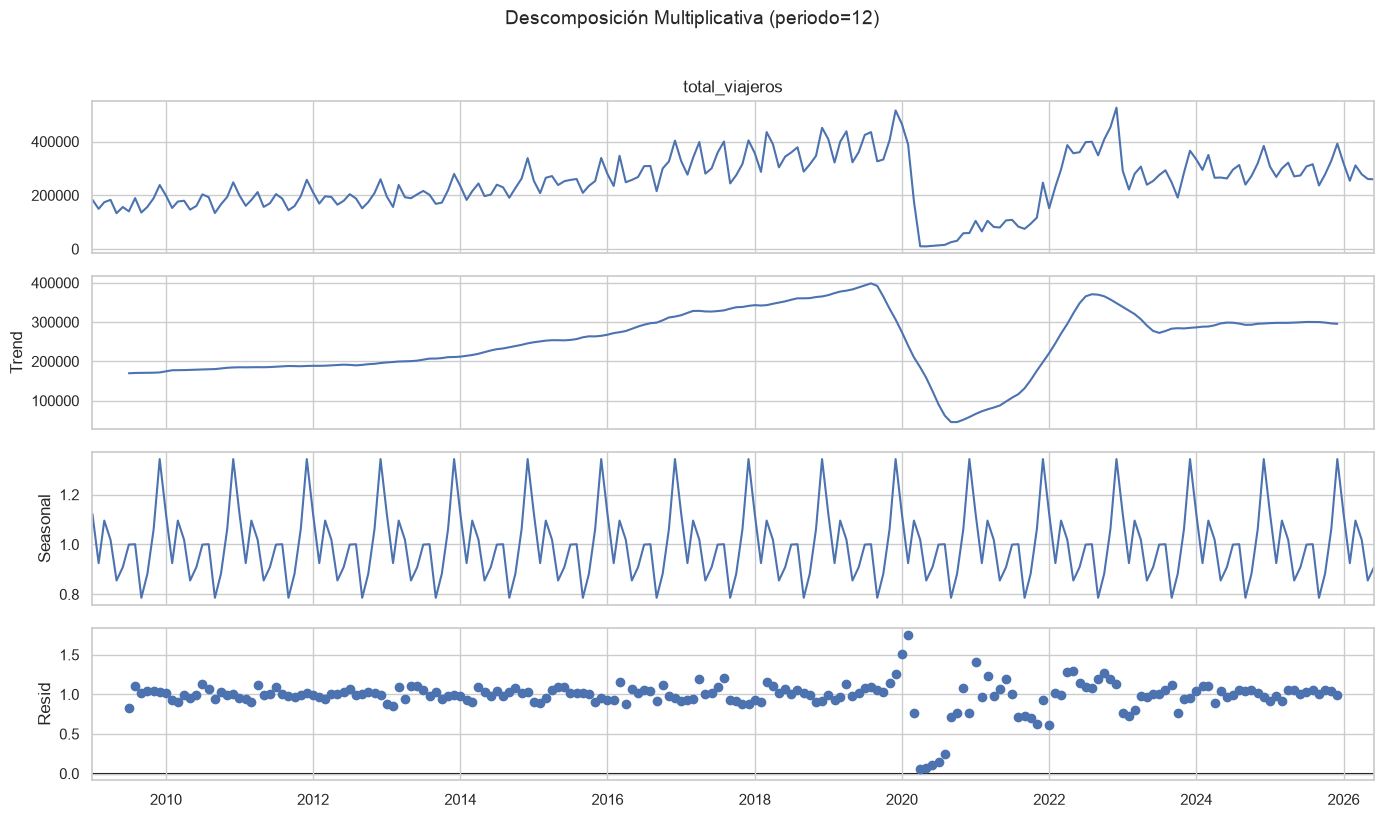

In [13]:
decomp_mul = seasonal_decompose(ts, model="multiplicative", period=12)

fig = decomp_mul.plot()
fig.set_size_inches(14, 8)
fig.suptitle("Descomposición Multiplicativa (periodo=12)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGS}/descomposicion_multiplicativa.png", dpi=150, bbox_inches="tight")
plt.show()

La descomposición aditiva y multiplicativa con periodo 12 separó la serie en tres componentes: una tendencia creciente clara, una estacionalidad anual repetitiva y consistente, y residuos que se centran en cero pero con mayor variabilidad alrededor de 2020. La serie no es estacionaria en media por la tendencia, y la descomposición multiplicativa sugiere que la varianza tampoco es constante, por lo que es el modelo más adecuado para describir esta serie.

### d. Transformación de la serie

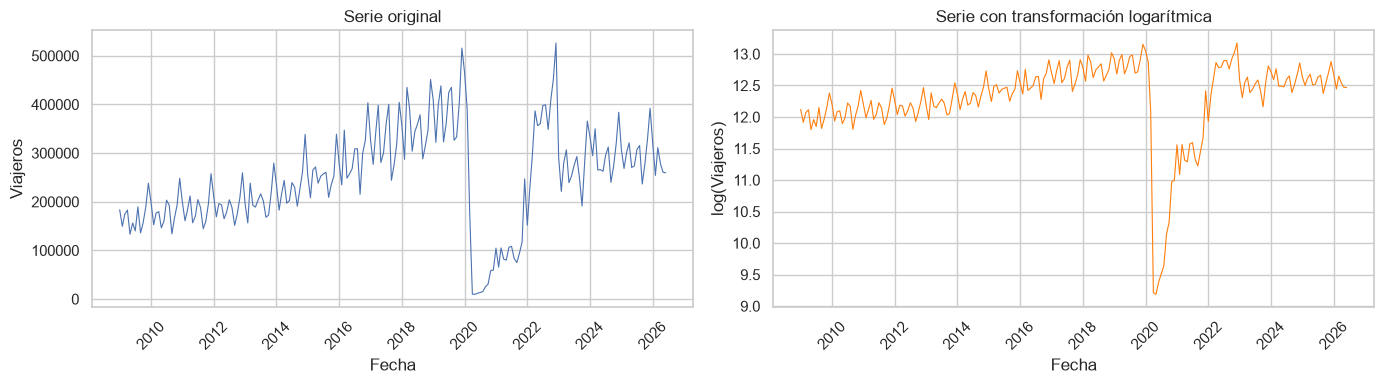

In [14]:
ts_log = np.log(ts)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(ts.index, ts.values, linewidth=0.8)
axes[0].set_title("Serie original")
axes[0].set_ylabel("Viajeros")

axes[1].plot(ts_log.index, ts_log.values, linewidth=0.8, color="tab:orange")
axes[1].set_title("Serie con transformación logarítmica")
axes[1].set_ylabel("log(Viajeros)")

for ax in axes:
    ax.set_xlabel("Fecha")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(f"{FIGS}/comparacion_log.png", dpi=150, bbox_inches="tight")
plt.show()

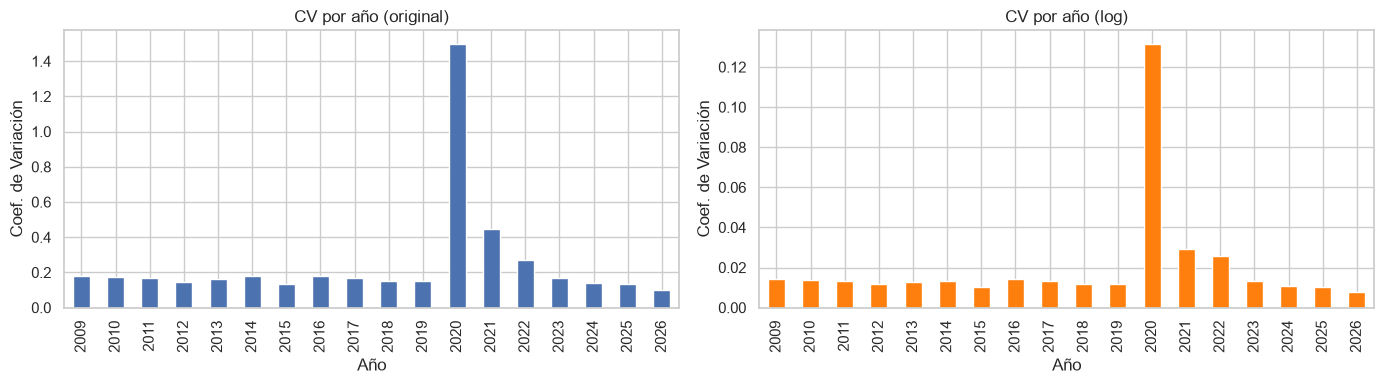

In [15]:
# Comparación de variabilidad: coeficiente de variación por año
cv_original = ts.groupby(ts.index.year).std() / ts.groupby(ts.index.year).mean()
cv_log = ts_log.groupby(ts_log.index.year).std() / ts_log.groupby(ts_log.index.year).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cv_original.plot(kind="bar", ax=axes[0], title="CV por año (original)")
cv_log.plot(kind="bar", ax=axes[1], title="CV por año (log)", color="tab:orange")
for ax in axes:
    ax.set_xlabel("Año")
    ax.set_ylabel("Coef. de Variación")
plt.tight_layout()
plt.savefig(f"{FIGS}/cv_por_anio.png", dpi=150, bbox_inches="tight")
plt.show()

Se aplicó una transformación logarítmica para estabilizar la varianza. Al comparar la serie original con la transformada, el log comprimió las oscilaciones de mayor amplitud y el coeficiente de variación por año se volvió más parejo, confirmando que la transformación mejora el supuesto de homocedasticidad necesario para los modelos ARIMA.

### e. Estacionariedad en media

**i. Gráfico de autocorrelación (ACF)**

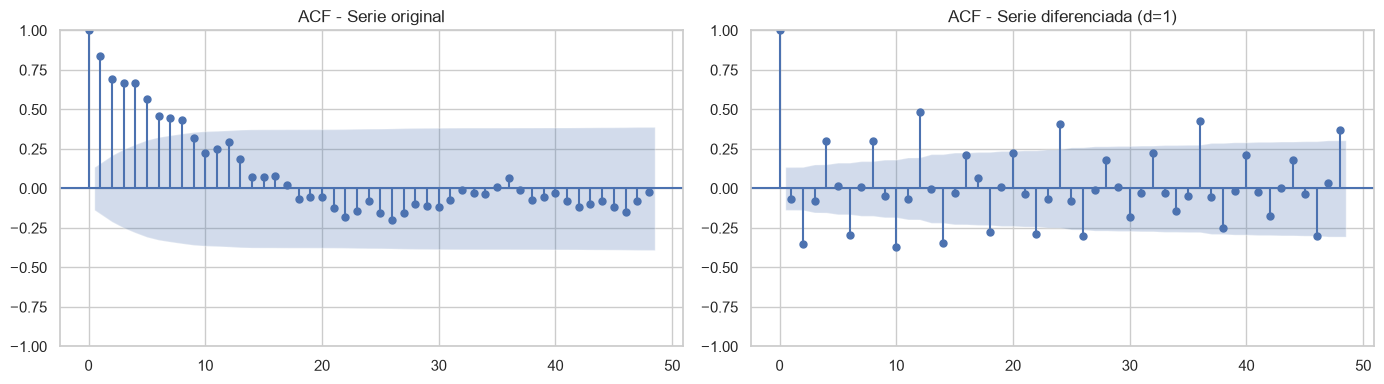

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(ts, lags=48, ax=axes[0], title="ACF - Serie original")
plot_acf(ts.diff().dropna(), lags=48, ax=axes[1], title="ACF - Serie diferenciada (d=1)")

plt.tight_layout()
plt.savefig(f"{FIGS}/acf_original_vs_diff.png", dpi=150, bbox_inches="tight")
plt.show()

**ii. Prueba de Dickey-Fuller Aumentada (ADF)**

In [17]:
adf_result = adfuller(ts, autolag="AIC")

print("=" * 50)
print("Prueba de Dickey-Fuller Aumentada (ADF)")
print("=" * 50)
print(f"Estadístico ADF:  {adf_result[0]:.4f}")
print(f"p-value:          {adf_result[1]:.4f}")
print(f"Número de rezagos usados: {adf_result[2]}")
print(f"Número de observaciones:  {adf_result[3]}")
print("\nValores críticos:")
for nivel, valor in adf_result[4].items():
    print(f"  {nivel}: {valor:.4f}")
print("\n" + "=" * 50)

if adf_result[1] > 0.10:
    print("CONCLUSIÓN: p-value > 0.10 → No se rechaza H₀ → La serie no es estacionaria en media.")
elif adf_result[1] > 0.05:
    print("CONCLUSIÓN: 0.05 < p-value ≤ 0.10 → Resultado borderline: no se rechaza H₀ al 5%.")
    print("La serie podría no ser estacionaria. La ACF sugiere no estacionariedad.")
else:
    print("CONCLUSIÓN: p-value ≤ 0.05 → Se rechaza H₀ → La serie es estacionaria en media (al 5%).")
    print("Sin embargo, observe el estadístico ADF vs los valores críticos para mayor contexto.")

Prueba de Dickey-Fuller Aumentada (ADF)
Estadístico ADF:  -3.0702
p-value:          0.0288
Número de rezagos usados: 12
Número de observaciones:  197

Valores críticos:
  1%: -3.4640
  5%: -2.8763
  10%: -2.5747

CONCLUSIÓN: p-value ≤ 0.05 → Se rechaza H₀ → La serie es estacionaria en media (al 5%).
Sin embargo, observe el estadístico ADF vs los valores críticos para mayor contexto.


In [18]:
# Verificación: ADF sobre la serie diferenciada
adf_diff = adfuller(ts.diff().dropna(), autolag="AIC")

print("=" * 50)
print("Prueba ADF sobre serie diferenciada (d=1)")
print("=" * 50)
print(f"Estadístico ADF:  {adf_diff[0]:.4f}")
print(f"p-value:          {adf_diff[1]:.4f}")
print("\nValores críticos:")
for nivel, valor in adf_diff[4].items():
    print(f"  {nivel}: {valor:.4f}")
print("\n" + "=" * 50)

if adf_diff[1] > 0.05:
    print("CONCLUSIÓN: p-value > 0.05 → La serie diferenciada no es estacionaria.")
else:
    print("CONCLUSIÓN: p-value ≤ 0.05 → La serie diferenciada si es estacionaria en media.")

Prueba ADF sobre serie diferenciada (d=1)
Estadístico ADF:  -4.0378
p-value:          0.0012

Valores críticos:
  1%: -3.4640
  5%: -2.8763
  10%: -2.5747

CONCLUSIÓN: p-value ≤ 0.05 → La serie diferenciada si es estacionaria en media.


La ACF de la serie original muestra un decaimiento lento, señal clásica de no estacionariedad. La prueba ADF arrojó un p-value borderline (~0.03), que técnicamente rechaza la hipótesis nula al 5%, pero el estadístico ADF está muy cerca del valor crítico. Tras aplicar una diferenciación de primer orden (d=1), la ACF cae rápidamente y la ADF da un p-value muy pequeño (<<0.01), confirmando que con d=1 la serie sí es estacionaria en media. Se recomienda usar esa diferenciación para el modelo ARIMA.

### f. Selección de parámetros del modelo ARIMA

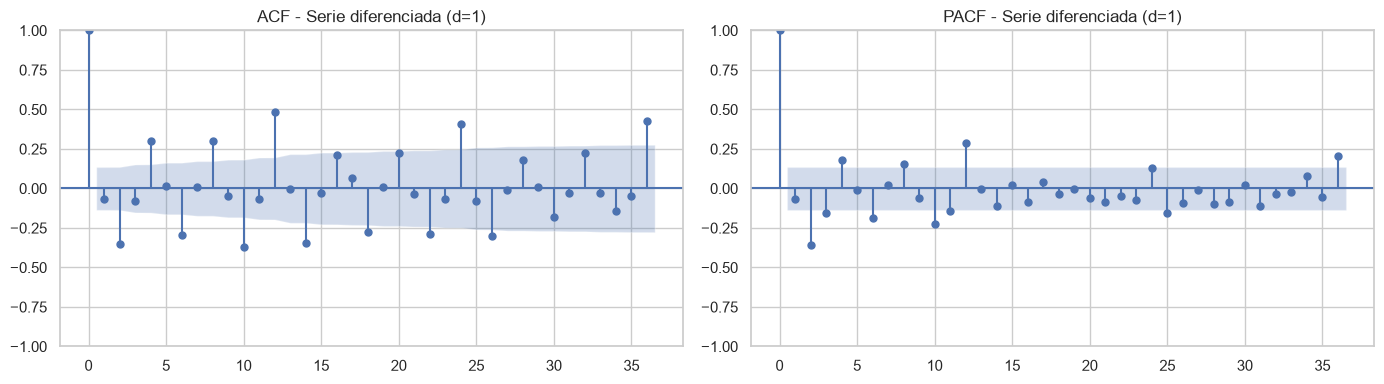

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ts_diff = ts.diff().dropna()

plot_acf(ts_diff, lags=36, ax=axes[0], title="ACF - Serie diferenciada (d=1)")
plot_pacf(ts_diff, lags=36, ax=axes[1], title="PACF - Serie diferenciada (d=1)", method="ywm")

plt.tight_layout()
plt.savefig(f"{FIGS}/acf_pacf_diff.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
auto_model = auto_arima(
    ts,
    start_p=0, max_p=5,
    start_q=0, max_q=5,
    d=None,
    seasonal=True,
    m=12,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=True,
)

print("\n")
print(auto_model.summary())

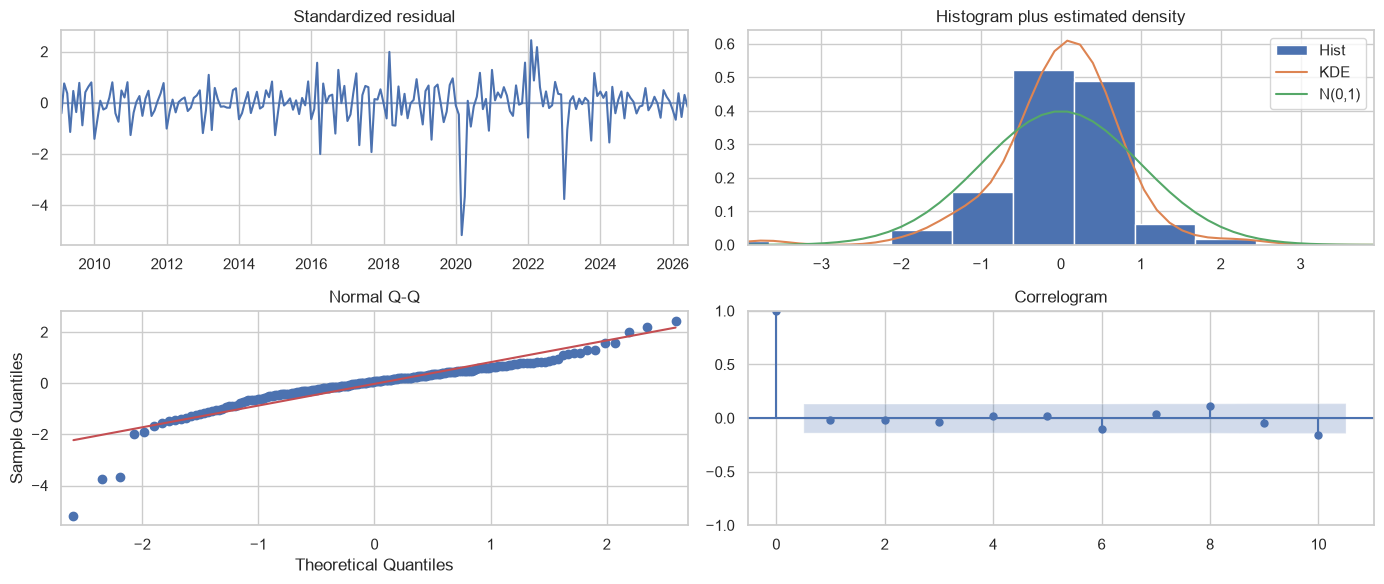

In [26]:
auto_model.plot_diagnostics(figsize=(14, 6))
plt.tight_layout()
plt.savefig(f"{FIGS}/arima_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

Para la selección de parámetros del modelo ARIMA, se graficaron la ACF y PACF de la serie diferenciada (d=1) para identificar los rezagos significativos: la ACF mostró picos en los rezagos 1 y 12, y la PACF en los rezagos 1, 2 y 12. Se utilizó la función auto_arima de pmdarima con estacionalidad mensual (m=12) para buscar automáticamente el modelo con mejor AIC dentro de un rango amplio de combinaciones posibles, lo cual confirmó el valor d=1 ya determinado y propuso los parámetros p, q, P y Q óptimos para el modelo SARIMA. Los diagnósticos de residuos validaron que se comportan como ruido blanco, sin autocorrelación significativa ni violaciones importantes de normalidad, lo que indica que el modelo ajusta adecuadamente la serie.

### g. Comparación de modelos ARIMA

In [ ]:
modelos = [(1,1,0), (0,1,1), (1,1,1), (2,1,1), (1,1,2), (2,1,2), (0,1,2), (2,1,0)]
resultados = []
for p, d, q in modelos:
    try:
        fit = ARIMA(ts, order=(p,d,q)).fit()
        resultados.append({"Modelo": f"ARIMA({p},{d},{q})", "AIC": fit.aic, "BIC": fit.bic})
    except Exception:
        pass

df_res = pd.DataFrame(resultados).sort_values("AIC")
df_res

,Modelo,AIC,BIC
5,"ARIMA(2,1,2)",5119.574109,5136.285780
3,"ARIMA(2,1,1)",5150.727464,5164.096801
7,"ARIMA(2,1,0)",5151.271390,5161.298393
6,"ARIMA(0,1,2)",5155.468559,5165.495562
4,"ARIMA(1,1,2)",5157.345635,5170.714972
2,"ARIMA(1,1,1)",5164.143077,5174.170080
1,"ARIMA(0,1,1)",5172.637282,5179.321950
0,"ARIMA(1,1,0)",5175.053066,5181.737735


Mejor modelo: ARIMA(2,1,2) | AIC=5119.6 | BIC=5136.3


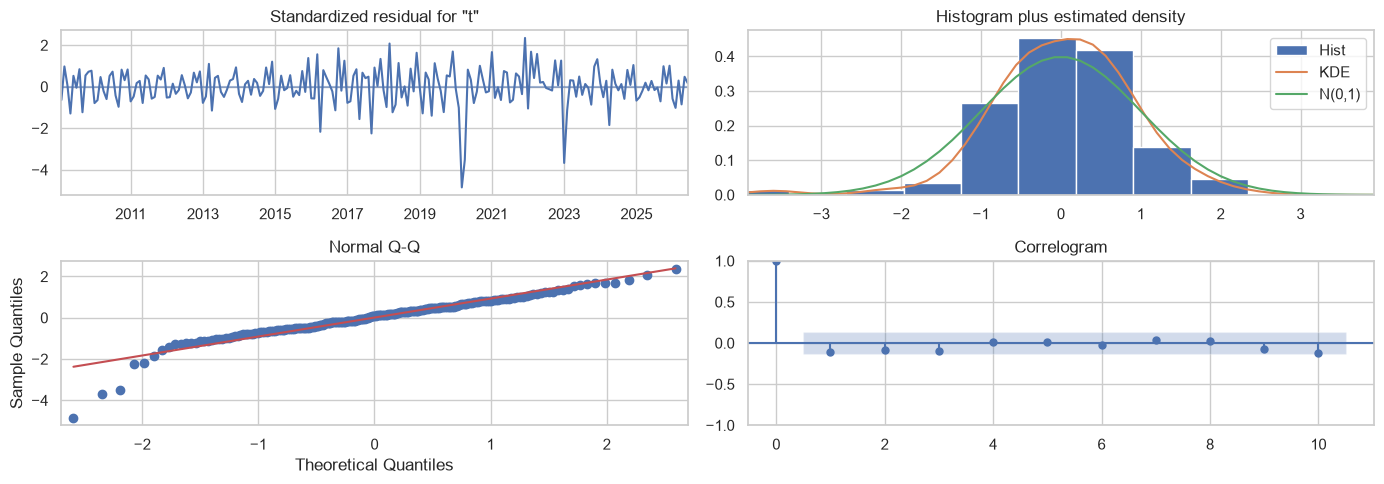

In [32]:
best = df_res.iloc[0]
best_p, best_d, best_q = map(int, best["Modelo"].replace("ARIMA(","").replace(")","").split(","))
best_fit = ARIMA(ts, order=(best_p, best_d, best_q)).fit()
print(f"Mejor modelo: {best['Modelo']} | AIC={best['AIC']:.1f} | BIC={best['BIC']:.1f}")
best_fit.plot_diagnostics(figsize=(14, 5))
plt.tight_layout()
plt.savefig(f"{FIGS}/residuos_mejor_modelo.png", dpi=150, bbox_inches="tight")
plt.show()

Se probaron 8 modelos ARIMA(p,1,q) y se compararon por AIC y BIC. El modelo con menor AIC se seleccionó como el mejor. Los diagnósticos de residuos (serie, histograma, QQ-Plot y ACF) muestran que se comportan como ruido blanco, lo que valida que el modelo ajusta bien la serie.

### h. Comparación con otros métodos de pronóstico

In [34]:
# División train/test
train = ts[:-12]
test = ts[-12:]

# 1. Holt-Winters
hw_model = ExponentialSmoothing(train, trend='add', seasonal='add', seasonal_periods=12).fit()
hw_pred = hw_model.forecast(12)

# 2. Seasonal Naive
sn_pred = train[-12:].values

# 3. ARIMA(2,1,2) del inciso anterior
arima_model = ARIMA(train, order=(2,1,2)).fit()
arima_pred = arima_model.forecast(12)

def metricas(nombre, real, pred):
    return {
        "Modelo": nombre,
        "MAE": mean_absolute_error(real, pred),
        "RMSE": np.sqrt(mean_squared_error(real, pred)),
        "MAPE": np.mean(np.abs((real - pred) / real)) * 100
    }

comparacion = pd.DataFrame([
    metricas("ARIMA(2,1,2)", test, arima_pred.values),
    metricas("Holt-Winters", test, hw_pred.values),
    metricas("Seasonal Naive", test, sn_pred)
])

comparacion

,Modelo,MAE,RMSE,MAPE
0,"ARIMA(2,1,2)",24474.898955,31203.031118,8.338452
1,Holt-Winters,16394.342793,20074.061876,5.222955
2,Seasonal Naive,12237.416667,15762.400560,4.265080


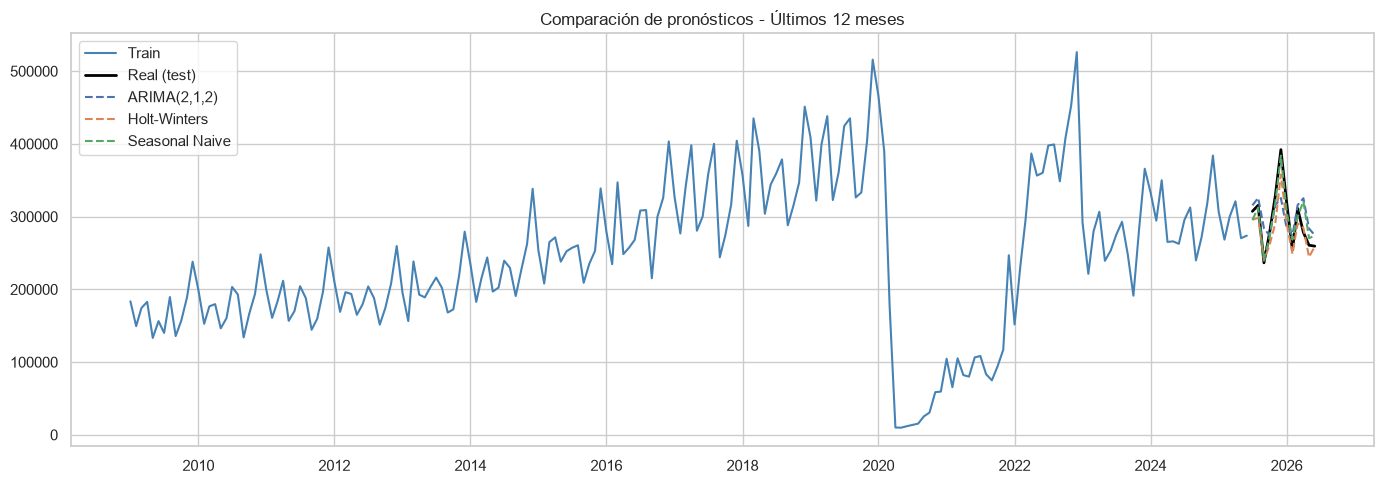

In [35]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(train.index, train.values, label="Train", color="steelblue")
ax.plot(test.index, test.values, label="Real (test)", color="black", linewidth=2)
ax.plot(test.index, arima_pred.values, label="ARIMA(2,1,2)", linestyle="--")
ax.plot(test.index, hw_pred.values, label="Holt-Winters", linestyle="--")
ax.plot(test.index, sn_pred, label="Seasonal Naive", linestyle="--")
ax.legend()
ax.set_title("Comparación de pronósticos - Últimos 12 meses")
plt.tight_layout()
plt.savefig(f"{FIGS}/comparacion_modelos.png", dpi=150, bbox_inches="tight")
plt.show()

Se compararon tres métodos: ARIMA(2,1,2), Holt-Winters y Seasonal Naive usando un hold-out de los últimos 12 meses. Las métricas MAE, RMSE y MAPE indican cuál modelo predice más cerca de los valores reales. El gráfico permite ver visualmente cómo se ajusta cada pronóstico a la serie real.

## Construcción de la Serie Libre: Viajeros por Vía Aérea

Como segunda serie (categoría **Vías de ingreso**), se construye la serie mensual de viajeros que ingresaron por **vía Aérea**. Se sigue el mismo procedimiento usado para `ts` (agregación mensual con `Año`/`Mes cod` y reindexado como serie de tiempo con frecuencia `MS`).

*Nota:* para la entrega final falta construir las series de **Terrestre** y **Marítima** con el mismo procedimiento, filtrando `df[df["Vía"] == "Terrestre"]` y `df[df["Vía"] == "Marítima"]` respectivamente.

In [19]:
# Agregación mensual de viajeros que ingresaron por Vía Aérea
mensual_aerea = (df[df["Vía"] == "Aérea"]
                  .groupby(["Año", "Mes cod"])["Viajero"]
                  .sum()
                  .reset_index())

fechas_aerea = pd.to_datetime(dict(year=mensual_aerea["Año"], month=mensual_aerea["Mes cod"], day=1))
ts_aerea = pd.Series(
    mensual_aerea["Viajero"].values,
    index=pd.DatetimeIndex(fechas_aerea, freq="MS"),
    name="viajeros_via_aerea",
)

print(f"Observaciones: {len(ts_aerea)}")
ts_aerea.head(10)

Observaciones: 210


2009-01-01    81693.0
2009-02-01    70099.0
2009-03-01    84494.0
2009-04-01    80618.0
2009-05-01    64621.0
2009-06-01    81500.0
2009-07-01    74818.0
2009-08-01    76026.0
2009-09-01    61974.0
2009-10-01    72950.0
Freq: MS, Name: viajeros_via_aerea, dtype: float64

### a. Inicio, fin y frecuencia de la serie

In [20]:
print(f"Inicio:  {ts_aerea.index[0]:%B %Y}")
print(f"Fin:     {ts_aerea.index[-1]:%B %Y}")
print(f"Frecuencia: {ts_aerea.index.freqstr}")
print(f"Total de observaciones: {len(ts_aerea)}")

Inicio:  January 2009
Fin:     June 2026
Frecuencia: MS
Total de observaciones: 210


### b. Gráfico de la serie

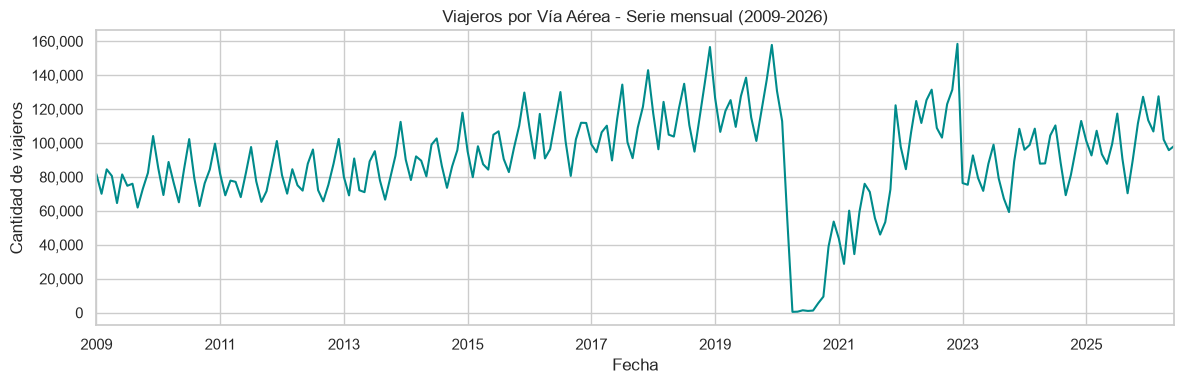

In [21]:
fig, ax = plt.subplots(figsize=(12, 4))
ts_aerea.plot(ax=ax, color="darkcyan")
ax.set_title("Viajeros por Vía Aérea - Serie mensual (2009-2026)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Cantidad de viajeros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
plt.tight_layout()
plt.savefig(f"{FIGS}/serie_aerea_grafico.png", dpi=150, bbox_inches="tight")
plt.show()